# Creating a YouTube popularity predictor

Predicting the number of views that a video will receive using only upload-time features such as the content creator details, the video title and description, is a highly challenging machine learning task, due to the numerous diverse factors that influence social media algorithms. In this notebook I'll demonstrate how to create and evaluate a baseline model for this task.

For comparison, The evaluation results of Calliope's ML engine are provided in a separate notebook. While Calliope was trained and evaluated on real YouTube data, for the baseline model here I will be using LLM-generated data that I've made publicly available. The data was created by prompting Gemini 2.5-flash to create imagined titles, descriptions and channel titles for 10,000 YouTube videos and an expected view count for each video at 2 weeks after publication.

### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import regex
from sentence_transformers import SentenceTransformer

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score, accuracy_score

In [ ]:
import matplotlib.pyplot as plt

### Import dataset

In [ ]:
video_metadata = pd.read_csv('video_metadata.csv')
video_metadata

,videoTitle,videoDescription,channelTitle,viewCount
0,Unleash Your Child's Inner Genius: Proven Memo...,Discover powerful and engaging memory techniqu...,MindBloom Education,580
1,রান্নাঘরের নক্ষত্র শেফ রিনা চৌধুরী এখন Purity ...,Purity Spices Co.-এর নতুন ব্র্যান্ড অ্যাম্বাসে...,Purity Spices Co. Official,1875
2,AH-64 Apache Ambush - Intense Ground Attack Si...,#arma3 #milsimarma3 #apachehelicopter #grounda...,Phantom Milsim,15
3,The Day Earth Almost Died 🌋☠️ #extinction #vol...,"250 million years ago, a catastrophe far worse...",Epoch Explorers,1150
4,Agar Aap 30 Din Tak Bina Soye Raho To Body Par...,Agar Aap 30 Din Tak Bina Soye Raho To Body Par...,BioQuest Shorts,230
...,...,...,...,...
9989,Modernizing Legacy Logistics with Quantum-Secu...,How a regional shipping firm tackled supply ch...,Enterprise Evolution Hub,1
9990,PyMOL Tutorial for Beginners: Master Molecular...,Unlock the power of molecular visualization wi...,Bio-Visualize Hub,550
9991,Debugging Your Reality: The Code Blocking Your...,Feeling like your manifestations are stuck in ...,The Reality Architect,444
9992,MHF4U (Grade 12 Advanced Functions) - Graphing...,Course Site - MHF4U Grade 12 Advanced Function...,MathMadeSimple,120


### Exploratory data analysis

First, let's check that the data is free of NaN values:

In [ ]:
video_metadata.isna().any()

,0
videoTitle,False
videoDescription,False
channelTitle,False
viewCount,False


Next, let's explore the target variable:

In [ ]:
video_metadata['viewCount'].describe()

,viewCount
count,9.994000e+03
mean,3.163503e+04
std,4.303213e+05
min,0.000000e+00
25%,7.500000e+01
50%,5.500000e+02
75%,2.150000e+03
max,2.500000e+07


The view count ranges over many orders of magnitude, from 0 to 25 million, with a median of 550. It will be useful to take the logarithm of the view count:

In [ ]:
video_metadata['logViewCount'] = np.log10(video_metadata['viewCount'] +1)

We can plot a histogram of the logarithmic view count:

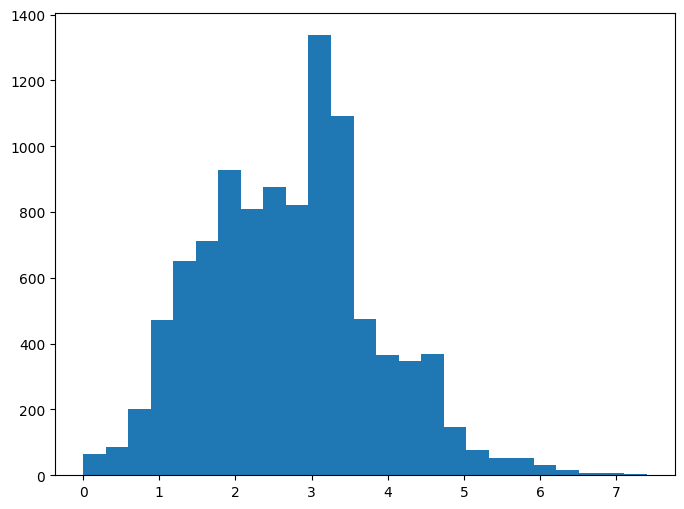

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

_ = ax.hist(video_metadata['logViewCount'].values, bins=25)

The log of the view count behaves as a random variable with a heavy right tail.



### Model design

The metadata contains three text features: the title and description of the video, and the title of the YouTube channel publishing the video. We will build a language model that takes in these three text features, converts them into embeddings using an LLM. We will first try ordinary linear regression, then XGBoost.

First, we will combine the three text features with feature headings into a single input text.

In [ ]:
text_cols = ['videoTitle', 'videoDescription', 'channelTitle']

In [ ]:
def combine_text_features(row, features):
    def escape_header(text, header):
        return regex.sub(rf'\[{header}\]', rf'[[{header}]]', text)

    combined_text = []
    for col in features:
        combined_text.append(f'[{col.upper()}]')
        combined_text.append(escape_header(row[col], col.upper()))
    return ' '.join(combined_text)

Applyiing this function to the first row we get:

In [ ]:
combine_text_features(video_metadata.iloc[0], text_cols)

"[VIDEOTITLE] Unleash Your Child's Inner Genius: Proven Memory Techniques for Academic Success [VIDEODESCRIPTION] Discover powerful and engaging memory techniques that can transform your child's learning and academic performance. This video shares actionable strategies for parents and students to enhance focus, retention, and overall brain power. Learn how to make studying fun and effective!\n#memorytechniques #childeducation #academicexcellence #parenting #learninghacks #studentsuccess #brainpower #studyguide #educationalvideo #mindtraining #schooltips #childdevelopment #motivation #smartlearning #mindfulnessforkids #memoryimprovement #examtips #education #learning #student #knowledge #teacher #children #college #university #learn #teaching #success #inspiration #studygram #parenting #onlinelearning #studentlife #leadership #family #support #mindpower #learn #thoughts #inspiration #dreams #goals #successquote #thepositivediaries #mindtrainer #mindcoach #abundance #happiness #powerofpo

We can now apply this to the entire dataset to obtain the model input.

In [ ]:
video_metadata['text'] = video_metadata.apply(lambda row: combine_text_features(row, text_cols), axis=1)

### Train-test split

We will reserve unseen data for later evaluation, and scale the target variable.

In [ ]:
train, test = train_test_split(video_metadata, test_size=0.2, random_state=42)

In [ ]:
target_scaler = StandardScaler()
target_scaler.fit(train[['logViewCount']])

StandardScaler()

In [ ]:
labels = target_scaler.transform(video_metadata[['logViewCount']]).flatten()

### Create the model

Let's create our text embeddings using a multilingual sentence transformer:

In [ ]:
sentence_transformer_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings = sentence_transformer_model.encode(video_metadata['text'].tolist())

In [ ]:
train_embeddings = embeddings[train.index,:]
train_targets = labels[train.index]

test_embeddings = embeddings[test.index,:]
test_targets = labels[test.index]

We are now ready to train a linear regressor.

In [ ]:
regressor = LinearRegression()

In [ ]:
regressor.fit(train_embeddings, train_targets)

LinearRegression()

### Model evaluation

Let's calculate the model predictions and score them against the labels:

In [ ]:
y_pred = regressor.predict(test_embeddings)

In [ ]:
r2_score(test_targets, y_pred)

0.17619243753902092

We see that the simplest method -- combining embeddings with ordinary linear regression already provides significant predictive value.

# XGBoost

Next, we can try the same with XGBoost. Let's install and import the library.

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
import xgboost as xgb

We will use the default hyperparameters, but use a validation set to monitor training, with an early stopping callback that ends training when the validation score stops improving.

In [ ]:
train_valsplit, val = train_test_split(train, test_size=0.2, random_state=24)

In [ ]:
def r2_callback(env):
    if env.iteration % 20 == 0:
        model = env.model

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_r2 = r2_score(y_train, train_pred)
        val_r2 = r2_score(y_val, val_pred)

        print(f"[{env.iteration}] train_r2={train_r2:.4f} val_r2={val_r2:.4f}")

In [ ]:
train_valsplit_embeddings = embeddings[train_valsplit.index, :]
train_valsplit_targets = labels[train_valsplit.index]

val_embeddings = embeddings[val.index,:]
val_targets = labels[val.index]

In [ ]:
dtrain = xgb.DMatrix(train_valsplit_embeddings, label=train_valsplit_targets)
dval = xgb.DMatrix(val_embeddings, label=val_targets)

In [ ]:
def r2_eval(preds, dmatrix):
    labels = dmatrix.get_label()
    return "r2", r2_score(labels, preds)

In [ ]:
import copy

class R2EarlyStopping(xgb.callback.TrainingCallback):
    def __init__(self, patience=100, eval_every=20):
        self.patience = patience
        self.eval_every = eval_every
        self.best_score = -np.inf
        self.best_iter = 0
        self.wait = 0
        self.best_model = None

    def after_iteration(self, model, epoch, evals_log):
        if epoch % self.eval_every != 0:
            return False

        train_pred = model.predict(dtrain)
        val_pred = model.predict(dval)

        train_r2 = r2_score(train_valsplit_targets, train_pred)
        val_r2 = r2_score(val_targets, val_pred)

        print(f"[{epoch:4d}] train_r2={train_r2:.4f} | val_r2={val_r2:.4f}")

        if val_r2 > self.best_score:
            self.best_score = val_r2
            self.best_iter = epoch
            self.wait = 0
            self.best_model = copy.deepcopy(model)  # 👈 key line
        else:
            self.wait += self.eval_every

        if self.wait >= self.patience:
            print(
                f"\nEarly stopping at iteration {epoch}"
                f"\nBest iteration: {self.best_iter}"
                f"\nBest val_r2: {self.best_score:.4f}"
            )
            return True
        return False

In [ ]:
params = {
    "objective": "reg:squarederror",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42,
}

In [ ]:
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=[(dtrain, "train"), (dval, "val")],
    callbacks=[R2EarlyStopping()],
    verbose_eval=False
)

[   0] train_r2=0.0208 | val_r2=0.0064
[  20] train_r2=0.3061 | val_r2=0.1089
[  40] train_r2=0.4682 | val_r2=0.1475
[  60] train_r2=0.5702 | val_r2=0.1555
[  80] train_r2=0.6445 | val_r2=0.1644
[ 100] train_r2=0.6994 | val_r2=0.1686
[ 120] train_r2=0.7423 | val_r2=0.1720
[ 140] train_r2=0.7750 | val_r2=0.1722
[ 160] train_r2=0.8046 | val_r2=0.1714
[ 180] train_r2=0.8280 | val_r2=0.1709
[ 200] train_r2=0.8481 | val_r2=0.1704
[ 220] train_r2=0.8692 | val_r2=0.1722
[ 240] train_r2=0.8859 | val_r2=0.1703
[ 260] train_r2=0.8987 | val_r2=0.1705
[ 280] train_r2=0.9115 | val_r2=0.1710
[ 300] train_r2=0.9220 | val_r2=0.1709
[ 320] train_r2=0.9317 | val_r2=0.1718

Early stopping at iteration 320
Best iteration: 220
Best val_r2: 0.1722


In [ ]:
dtest = xgb.DMatrix(test_embeddings)

y_pred = model.predict(dtest)

Let's evaluate the model:

In [ ]:
r2_score(test_targets, y_pred)

0.20261255609717277

XGBoost does not offer significant improvement over linear regression, with a best validation R$^2$ of 0.172 and a test R$^2$ of 0.203 compared to 0.176 for linear regression. This suggests that the relationship between the text in embedding space and the logarithm of the view count can be modelled linearly, although it is very noisy.

Fortunately, Calliope's ML engine performs a lot better, with R$^2$ in excess of 0.7 on real data. A detailed report is provided in a separate notebook.